# Dataset Preprocessing for CBIR

This notebook prepares the Corel-1k dataset for Content-Based Image Retrieval (CBIR).
Steps include:
- Loading dataset
- Checking folder structure
- Visualizing sample images
- Resizing images

In [1]:
import os
import cv2
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Path to dataset folder
DATASET_PATH = "dataset"

# Get all category folders
categories = os.listdir(DATASET_PATH)

print("Categories:", categories)
print("Total categories:", len(categories))

Categories: ['ambulance', 'bicycle', 'bus', 'car', 'fire_truck', 'motorcycle', 'tractor', 'truck', 'van']
Total categories: 9


In [3]:
# Count number of images in each category
for category in categories:
    category_path = os.path.join(DATASET_PATH, category)
    num_images = len(os.listdir(category_path))
    print(f"{category}: {num_images} images")

ambulance: 372 images
bicycle: 334 images
bus: 282 images
car: 886 images
fire_truck: 257 images
motorcycle: 270 images
tractor: 309 images
truck: 259 images
van: 243 images


## Display Sample Images
We visualize a few images from each category to understand the dataset.

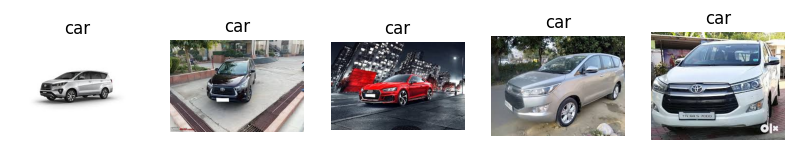

In [4]:
def show_sample_images(category, num_samples=5):
    category_path = os.path.join(DATASET_PATH, category)
    images = os.listdir(category_path)[:num_samples]
    
    plt.figure(figsize=(10, 3))
    
    for i, img_name in enumerate(images):
        img_path = os.path.join(category_path, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
        
        plt.subplot(1, num_samples, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(category)
    
    plt.show()

# Example: show beaches
show_sample_images("car")

# can test other categories like: 
# show_sample_images("motorcycle")
# show_sample_images("truck")

In [5]:
BALANCED_PATH = "balanced_dataset"
SAMPLE_SIZE = 200

random.seed(42) 

os.makedirs(BALANCED_PATH, exist_ok=True)

for category in os.listdir(DATASET_PATH):
    category_path = os.path.join(DATASET_PATH, category)

    if not os.path.isdir(category_path):
        continue

    images = [
        f for f in os.listdir(category_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    if len(images) <= SAMPLE_SIZE:
        selected_images = images
        print(f"{category}: only {len(images)} images (used all)")
    else:
        selected_images = random.sample(images, SAMPLE_SIZE)
        print(f"{category}: sampled {SAMPLE_SIZE} images")

    output_category_path = os.path.join(BALANCED_PATH, category)
    os.makedirs(output_category_path, exist_ok=True)

    for img_name in selected_images:
        src = os.path.join(category_path, img_name)
        dst = os.path.join(output_category_path, img_name)
        shutil.copy(src, dst)

print("Balanced dataset created!")

ambulance: sampled 200 images
bicycle: sampled 200 images
bus: sampled 200 images
car: sampled 200 images
fire_truck: sampled 200 images
motorcycle: sampled 200 images
tractor: sampled 200 images
truck: sampled 200 images
van: sampled 200 images
Balanced dataset created!


## Image Resizing

All images will be resized to a fixed size (e.g., 256x256)  
This ensures consistency for feature extraction.

In [6]:
# Resize all images and store in new folder
OUTPUT_PATH = "processed_dataset"
IMG_SIZE = (256, 256)

os.makedirs(OUTPUT_PATH, exist_ok=True)

valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

for category in categories:
    input_path = os.path.join(BALANCED_PATH, category)
    output_path = os.path.join(OUTPUT_PATH, category)

    os.makedirs(output_path, exist_ok=True)

    for img_name in os.listdir(input_path):
        img_path = os.path.join(input_path, img_name)

        # Skip non-image files
        if not img_name.lower().endswith(valid_ext):
            print("Skipped non-image file:", img_name)
            continue

        img = cv2.imread(img_path)

        # Skip unreadable images
        if img is None:
            print("Skipped unreadable image:", img_path)
            continue

        # Resize image
        img_resized = cv2.resize(img, IMG_SIZE)

        # Force output file to .jpg if extension is problematic
        base_name = os.path.splitext(img_name)[0]
        save_name = base_name + ".jpg"
        save_path = os.path.join(output_path, save_name)

        cv2.imwrite(save_path, img_resized)

print("Resizing completed!")

Resizing completed!


## Verify Processed Images
Check whether resizing is successful.

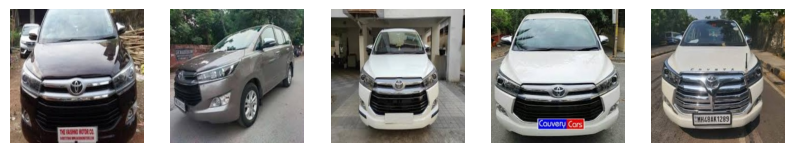

In [7]:
# Check one category after processing
def show_processed_sample(category):
    path = os.path.join(OUTPUT_PATH, category)
    images = os.listdir(path)[:5]
    
    plt.figure(figsize=(10, 3))
    
    for i, img_name in enumerate(images):
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.axis('off')
    
    plt.show()

show_processed_sample("car")